<a href="https://colab.research.google.com/github/mugaruram/MSc.-FIT/blob/main/NDVI_Temp_Precip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Project: Integrated Remote Sensing and Climate–Hydrology Modelling for Vegetation Trend Analysis in Tigrovaya Balka State Nature Reserve
Author: Michael Mugarura (2025)

THIRD-PARTY ATTRIBUTIONS (retain when reusing):

Source & Lincense:

*   MIT & BSD-3-Clause usage patterns
*   Parts of Code re-authored for thesis.

Thesis citation:
Mugarura, M. (2025). Integrated Remote Sensing and Climate–Hydrology Modelling for Vegetation Trend Analysis in Tigrovaya Balka State Nature Reserve. MSc Thesis, HNEE.





In [ ]:
!pip install pandas seaborn matplotlib


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipython-input-2608168148.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], x="Season", y="Temp_0C", data=data, palette={"Wet": "blue", "Dry": "red"})


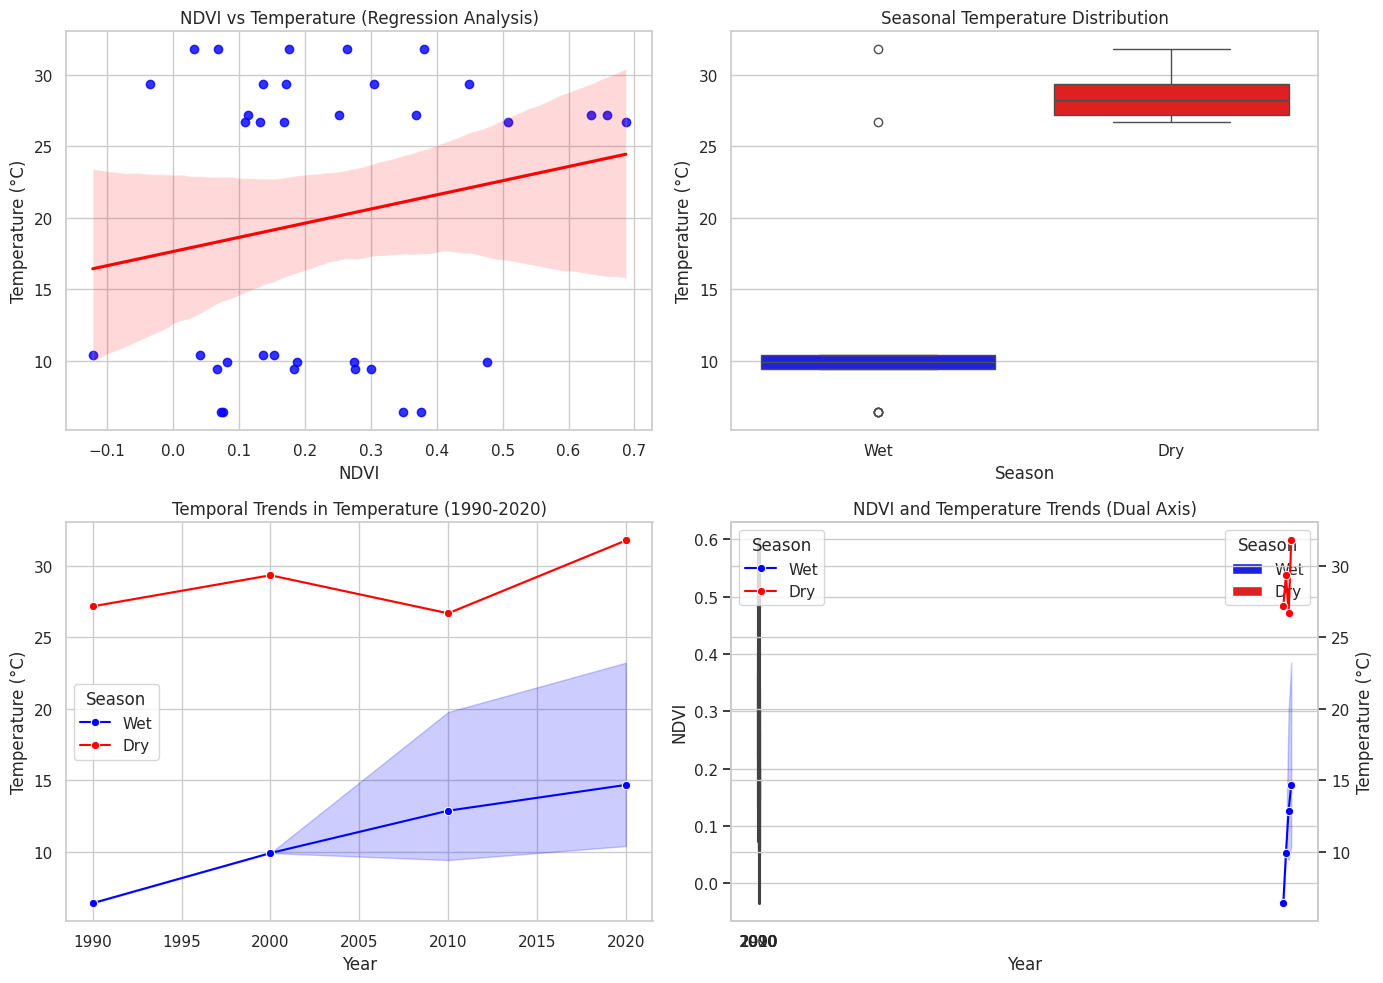

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame (ensuring all lists are of the same length)
data = pd.DataFrame({
    "YEAR": [2020, 2010, 2000, 1990] * 9,  # Ensuring equal-length arrays
    "NDVI": [-0.12188, 0.27571, 0.27463, 0.37663, 0.15264, 0.18422, 0.47586, 0.07562,
             0.13599, 0.30099, 0.18836, 0.34914, 0.04113, 0.06621, 0.08254, 0.07226,
             0.26409, 0.10894, 0.30442, 0.65896, 0.38113, 0.68702, 0.17129, 0.63471,
             0.06880, 0.13122, 0.44924, 0.11440, 0.17572, 0.50853, 0.13586, 0.36840,
             0.03106, 0.16811, -0.03441, 0.25150],  # Corrected array length
    "Season": ["Wet"] * 18 + ["Dry"] * 18,  # Ensuring 36 total values
    "Temp_0C": [10.4, 9.42, 9.91, 6.41, 10.4, 9.42, 9.91, 6.41,
                10.4, 9.42, 9.91, 6.41, 10.4, 9.42, 9.91, 6.41,
                31.76, 26.67, 29.33, 27.16, 31.76, 26.67, 29.33, 27.16,
                31.76, 26.67, 29.33, 27.16, 31.76, 26.67, 29.33, 27.16,
                31.76, 26.67, 29.33, 27.16]  # Corrected length
})

# Set theme for aesthetics
sns.set_theme(style="whitegrid")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter Plot: NDVI vs. Temperature (Regression)
sns.regplot(ax=axes[0, 0], x="NDVI", y="Temp_0C", data=data, scatter_kws={'color': 'blue'}, line_kws={"color": "red"})
axes[0, 0].set_title("NDVI vs Temperature (Regression Analysis)")
axes[0, 0].set_xlabel("NDVI")
axes[0, 0].set_ylabel("Temperature (°C)")

# Box Plot: Temperature distribution per season
sns.boxplot(ax=axes[0, 1], x="Season", y="Temp_0C", data=data, palette={"Wet": "blue", "Dry": "red"})
axes[0, 1].set_title("Seasonal Temperature Distribution")
axes[0, 1].set_ylabel("Temperature (°C)")

# Line Plot: Temporal Temperature Trends
sns.lineplot(ax=axes[1, 0], x="YEAR", y="Temp_0C", hue="Season", data=data, marker="o", palette={"Wet": "blue", "Dry": "red"})
axes[1, 0].set_title("Temporal Trends in Temperature (1990-2020)")
axes[1, 0].set_ylabel("Temperature (°C)")
axes[1, 0].set_xlabel("Year")

# Dual-Axis Plot: NDVI & Temperature per Year
ax1 = axes[1, 1]
ax2 = ax1.twinx()
sns.barplot(ax=ax1, x="YEAR", y="NDVI", data=data, hue="Season", palette={"Wet": "blue", "Dry": "red"})
sns.lineplot(ax=ax2, x="YEAR", y="Temp_0C", data=data, hue="Season", marker="o", palette={"Wet": "blue", "Dry": "red"})
ax1.set_title("NDVI and Temperature Trends (Dual Axis)")
ax1.set_xlabel("Year")
ax1.set_ylabel("NDVI")
ax2.set_ylabel("Temperature (°C)")

# Adjust layout and show plot
plt.tight_layout()
plt.show()


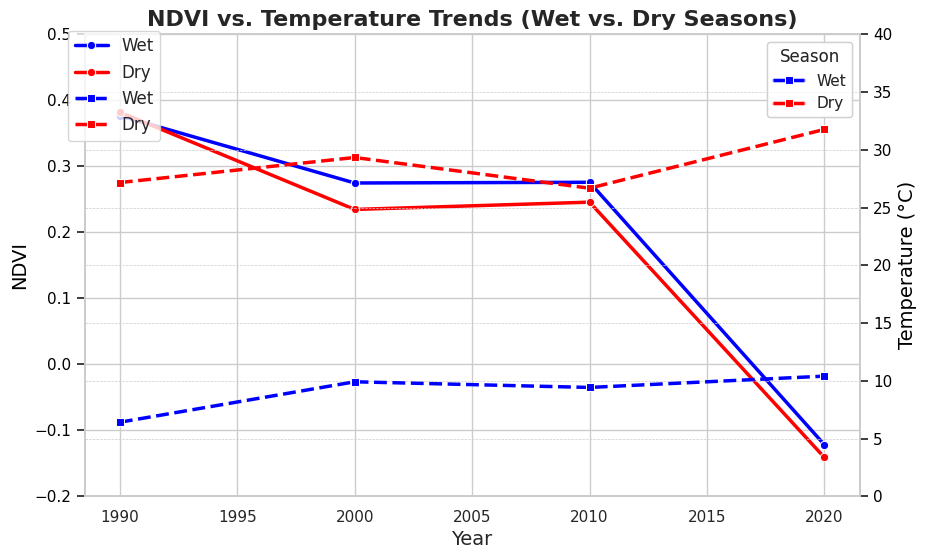

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame
data = pd.DataFrame({
    "YEAR": [2020, 2010, 2000, 1990] * 2,  # Repeat for Wet/Dry
    "NDVI": [-0.12188, 0.27571, 0.27463, 0.37663,  # Wet Season
             -0.1412, 0.24559, 0.23456, 0.38189],  # Dry Season
    "Season": ["Wet"] * 4 + ["Dry"] * 4,
    "Temp_0C": [10.4, 9.42, 9.91, 6.41,  # Wet Season
                31.76, 26.67, 29.33, 27.16],  # Dry Season
})

# Set style
sns.set_theme(style="whitegrid")

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Define color palette
colors = {"Wet": "blue", "Dry": "red"}

# Plot NDVI trends (Primary Y-axis)
sns.lineplot(data=data, x="YEAR", y="NDVI", hue="Season", marker="o", ax=ax1, palette=colors, linewidth=2.5)
ax1.set_ylabel("NDVI", fontsize=14, color="black")
ax1.set_xlabel("Year", fontsize=14)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(-0.2, 0.5)  # Set appropriate range for NDVI

# Create secondary Y-axis for Temperature
ax2 = ax1.twinx()
sns.lineplot(data=data, x="YEAR", y="Temp_0C", hue="Season", marker="s", linestyle="dashed", ax=ax2, palette=colors, linewidth=2.5)
ax2.set_ylabel("Temperature (°C)", fontsize=14, color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(0, 40)  # Adjust based on temperature range

# Title and legend adjustments
plt.title("NDVI vs. Temperature Trends (Wet vs. Dry Seasons)", fontsize=16, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9), fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5)

# Show the plot
plt.show()


In [ ]:
#!pip install pandas seaborn matplotlib pdfplumber
!pip install ace-tools
!pip install ace-tools-open

In [ ]:
!pip install pdfplumber

In [10]:
import pandas as pd

# Load the PDF file and extract text
#pdf_path = "/mnt/data/NDVI-Temp_Data.pdf"
pdf_path = "/content/NDVI-Temp_Data.pdf"

# Extract text from the PDF
import pdfplumber

data_list = []
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            lines = text.split("\n")
            for line in lines:
                parts = line.split()
                if len(parts) == 6:  # Ensure there are six columns
                    try:
                        year = int(parts[0])
                        ndvi = float(parts[1])
                        season = parts[2]
                        evi = float(parts[3])
                        temp = float(parts[4]) if parts[4] != "NA" else None  # Handle NA
                        precip = float(parts[5]) if parts[5] != "NA" else None  # Handle NA
                        data_list.append([year, ndvi, season, evi, temp, precip])
                    except ValueError:
                        continue

# Convert extracted data to a DataFrame
columns = ["YEAR", "NDVI", "Season", "EVI", "Temp_0C", "Precip_cm"]
df = pd.DataFrame(data_list, columns=columns)

# Fill missing values using linear interpolation
df["Temp_0C"].interpolate(method="linear", inplace=True)
df["Precip_cm"].interpolate(method="linear", inplace=True)

# Display the cleaned DataFrame
import ace_tools_open as tools;
tools.display_dataframe_to_user(name="Cleaned NDVI-Temp Data", dataframe=df)

/tmp/ipython-input-2532523392.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Temp_0C"].interpolate(method="linear", inplace=True)
/tmp/ipython-input-2532523392.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Cleaned NDVI-Temp Data


Loading ITables v2.5.2 from the internet... (need help?)


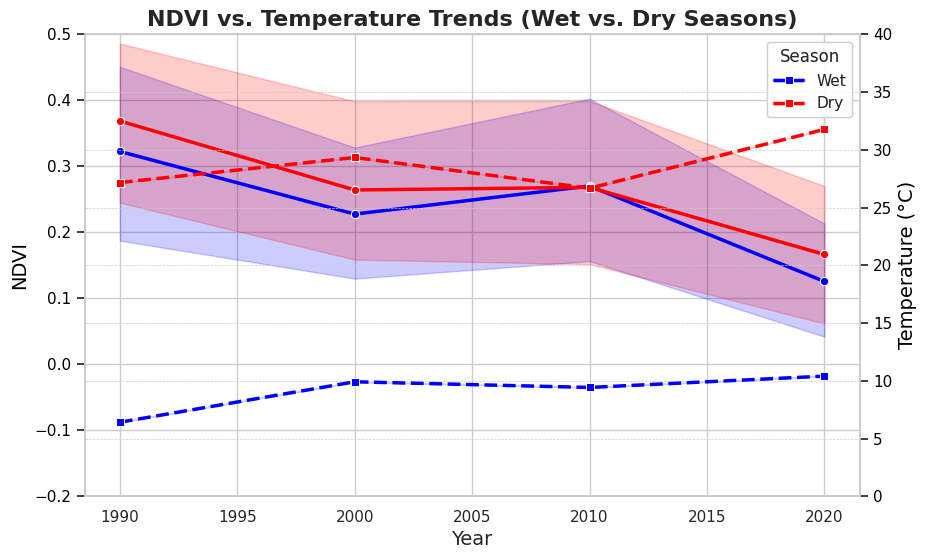

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#

# Set style
sns.set_theme(style="whitegrid")

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Define color palette
colors = {"Wet": "blue", "Dry": "red"}

# Plot NDVI trends (Primary Y-axis)
sns.lineplot(data=df, x="YEAR", y="NDVI", hue="Season", marker="o", ax=ax1, palette=colors, linewidth=2.5)
ax1.set_ylabel("NDVI", fontsize=14, color="black")
ax1.set_xlabel("Year", fontsize=14)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(-0.2, 0.5)  # Set appropriate range for NDVI

# Create secondary Y-axis for Temperature
ax2 = ax1.twinx()
sns.lineplot(data=df, x="YEAR", y="Temp_0C", hue="Season", marker="s", linestyle="dashed", ax=ax2, palette=colors, linewidth=2.5)
ax2.set_ylabel("Temperature (°C)", fontsize=14, color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(0, 40)  # Adjust based on temperature range

# Title and legend adjustments
plt.title("NDVI vs. Temperature Trends (Wet vs. Dry Seasons)", fontsize=16, fontweight="bold")
#fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9), fontsize=12)
plt.grid(True, linestyle="--", linewidth=0.5)

# Show the plot
plt.show()

/tmp/ipython-input-7573035.py:27: UserWarning: 
The dashes list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  precip_plot = sns.lineplot(


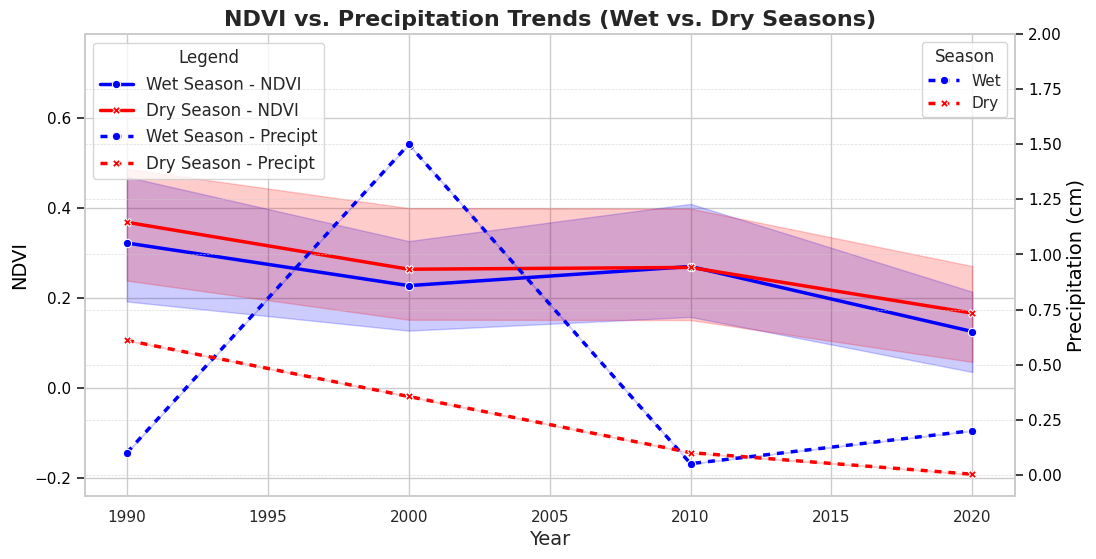

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🔹 Set seaborn style for better visualization
sns.set_theme(style="whitegrid")

# 🔹 Define color mapping for Wet and Dry seasons
colors = {"Wet": "blue", "Dry": "red"}

# 🔹 Create a figure and axis for NDVI (Primary Y-axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 🔹 Plot NDVI trends on the primary Y-axis (solid lines)
# Removed the 'label' argument here to avoid conflict with 'hue' and 'style'
ndvi_plot = sns.lineplot(
    data=df, x="YEAR", y="NDVI", hue="Season", style="Season",
    markers=True, dashes=False, ax=ax1, palette=colors, linewidth=2.5
)
ax1.set_ylabel("NDVI", fontsize=14, color="black")
ax1.set_xlabel("Year", fontsize=14)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(df["NDVI"].min() - 0.1, df["NDVI"].max() + 0.1)  # Adjust range dynamically

# 🔹 Create a secondary Y-axis for Precipitation (dashed lines)
ax2 = ax1.twinx()
precip_plot = sns.lineplot(
    data=df, x="YEAR", y="Precip_cm", hue="Season", style="Season",
    markers=True, dashes=[(2, 2)], ax=ax2, palette=colors, linewidth=2.5,  # Disable the second legend # Remove the label argument here
)
ax2.set_ylabel("Precipitation (cm)", fontsize=14, color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(df["Precip_cm"].min() - 0.1, df["Precip_cm"].max() + 0.5)

# 🔹 Combine legends into a **single unified legend**
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# 🔹 Ensure only **one merged legend** with clear labels
legend_labels = ["Wet Season - NDVI", "Dry Season - NDVI", "Wet Season - Precipt", "Dry Season - Precipt"]
ax1.legend(
    handles1[:2] + handles2[:2],  # Select corresponding handles for clarity
    legend_labels, loc="upper left", fontsize=12, title="Legend"
)

# 🔹 Add title and enhance gridlines
plt.title("NDVI vs. Precipitation Trends (Wet vs. Dry Seasons)", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# 🔹 Display the improved plot
plt.show()

In [13]:
import pandas as pd

# Load the PDF file and extract text
#pdf_path = "/mnt/data/NDVI-Temp_Data.pdf"
pdf_path = "/content/NDVI-Temp_Data.pdf"

# Extract text from the PDF
import pdfplumber

data_list = []
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            lines = text.split("\n")
            for line in lines:
                parts = line.split()
                if len(parts) == 6:  # Ensure there are six columns
                    try:
                        year = int(parts[0])
                        ndvi = float(parts[1])
                        season = parts[2]
                        evi = float(parts[3])
                        temp = float(parts[4]) if parts[4] != "NA" else None  # Handle NA
                        precip = float(parts[5]) if parts[5] != "NA" else None  # Handle NA
                        data_list.append([year, ndvi, season, evi, temp, precip])
                    except ValueError:
                        continue

# Convert extracted data to a DataFrame
columns = ["YEAR", "NDVI", "Season", "EVI", "Temp_0C", "Precip_cm"]
df = pd.DataFrame(data_list, columns=columns)

# Fill missing values using linear interpolation
df["Temp_0C"].interpolate(method="linear", inplace=True)
df["Precip_cm"].interpolate(method="linear", inplace=True)

# Display the cleaned DataFrame
# Removed dependency on ace_tools as this library is not installed.
# Using pandas to display the DataFrame instead.
print("Cleaned NDVI-Temp Data")
display(df)

Cleaned NDVI-Temp Data


/tmp/ipython-input-557442781.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Temp_0C"].interpolate(method="linear", inplace=True)
/tmp/ipython-input-557442781.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,YEAR,NDVI,Season,EVI,Temp_0C,Precip_cm
0,2020,-0.121880,Wet,-0.493100,10.40,0.200
1,2010,0.275705,Wet,0.145759,9.42,0.050
2,2000,0.274633,Wet,0.129855,9.91,1.500
3,1990,0.376631,Wet,0.205090,6.41,0.100
4,2020,0.152645,Wet,0.649502,10.40,0.200
...,...,...,...,...,...,...
67,1990,0.564484,Dry,0.414397,27.16,0.610
68,2020,0.138983,Dry,0.406150,31.76,0.002
69,2010,0.304059,Dry,0.129637,26.67,0.100
70,2000,0.336530,Dry,0.146514,29.33,0.355


/tmp/ipython-input-1160314846.py:26: UserWarning: 
The dashes list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  temp_plot = sns.lineplot(


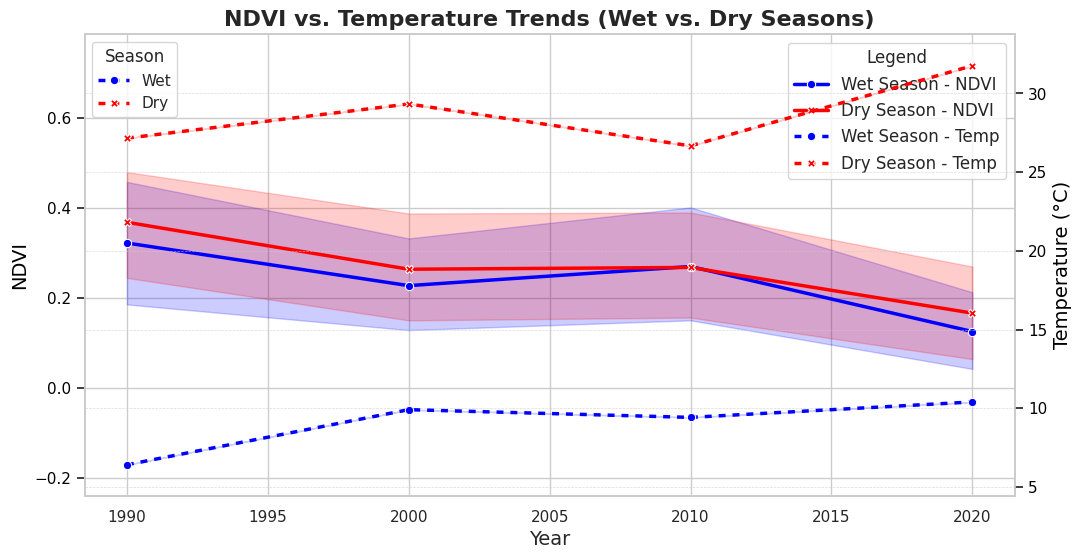

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🔹 Set seaborn style for better visualization
sns.set_theme(style="whitegrid")

# 🔹 Define color mapping for Wet and Dry seasons
colors = {"Wet": "blue", "Dry": "red"}

# 🔹 Create a figure and axis for NDVI (Primary Y-axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 🔹 Plot NDVI trends on the primary Y-axis (solid lines)
ndvi_plot = sns.lineplot(
    data=df, x="YEAR", y="NDVI", hue="Season", style="Season",
    markers=True, dashes=False, ax=ax1, palette=colors, linewidth=2.5
)
ax1.set_ylabel("NDVI", fontsize=14, color="black")
ax1.set_xlabel("Year", fontsize=14)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(df["NDVI"].min() - 0.1, df["NDVI"].max() + 0.1)  # Adjust range dynamically

# 🔹 Create a secondary Y-axis for Temperature (dashed lines)
ax2 = ax1.twinx()
temp_plot = sns.lineplot(
    data=df, x="YEAR", y="Temp_0C", hue="Season", style="Season",
    markers=True, dashes=[(2, 2)], ax=ax2, palette=colors, linewidth=2.5 , legend = True
)
ax2.set_ylabel("Temperature (°C)", fontsize=14, color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(df["Temp_0C"].min() - 2, df["Temp_0C"].max() + 2)  # Adjust temperature range as needed


# 🔹 Combine legends into a single unified legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# 🔹 Ensure only one merged legend with clear labels
legend_labels = ["Wet Season - NDVI", "Dry Season - NDVI", "Wet Season - Temp", "Dry Season - Temp"]
ax1.legend(
    handles1[:2] + handles2[:2],  # Select corresponding handles for clarity
    legend_labels, loc="upper right", fontsize=12, title="Legend"
)

# 🔹 Add title and enhance gridlines
plt.title("NDVI vs. Temperature Trends (Wet vs. Dry Seasons)", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# 🔹 Display the improved plot
plt.show()

/tmp/ipython-input-1160314846.py:26: UserWarning: 
The dashes list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  temp_plot = sns.lineplot(


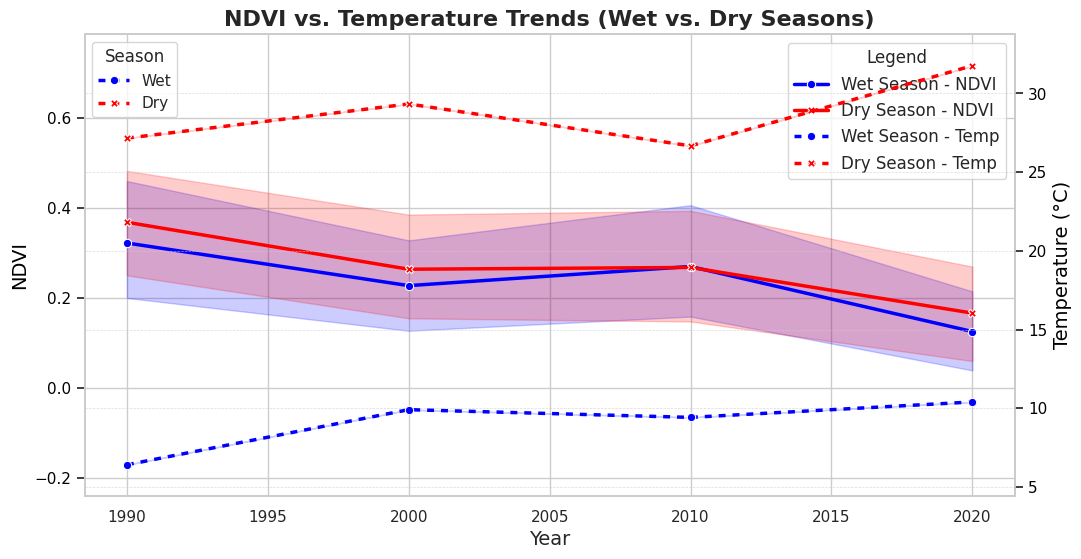

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🔹 Set seaborn style for better visualization
sns.set_theme(style="whitegrid")

# 🔹 Define color mapping for Wet and Dry seasons
colors = {"Wet": "blue", "Dry": "red"}

# 🔹 Create a figure and axis for NDVI (Primary Y-axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 🔹 Plot NDVI trends on the primary Y-axis (solid lines)
ndvi_plot = sns.lineplot(
    data=df, x="YEAR", y="NDVI", hue="Season", style="Season",
    markers=True, dashes=False, ax=ax1, palette=colors, linewidth=2.5
)
ax1.set_ylabel("NDVI", fontsize=14, color="black")
ax1.set_xlabel("Year", fontsize=14)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(df["NDVI"].min() - 0.1, df["NDVI"].max() + 0.1)  # Adjust range dynamically

# 🔹 Create a secondary Y-axis for Temperature (dashed lines)
ax2 = ax1.twinx()
temp_plot = sns.lineplot(
    data=df, x="YEAR", y="Temp_0C", hue="Season", style="Season",
    markers=True, dashes=[(2, 2)], ax=ax2, palette=colors, linewidth=2.5 , legend = True
)
ax2.set_ylabel("Temperature (°C)", fontsize=14, color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(df["Temp_0C"].min() - 2, df["Temp_0C"].max() + 2)  # Adjust temperature range as needed


# 🔹 Combine legends into a single unified legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# 🔹 Ensure only one merged legend with clear labels
legend_labels = ["Wet Season - NDVI", "Dry Season - NDVI", "Wet Season - Temp", "Dry Season - Temp"]
ax1.legend(
    handles1[:2] + handles2[:2],  # Select corresponding handles for clarity
    legend_labels, loc="upper right", fontsize=12, title="Legend"
)

# 🔹 Add title and enhance gridlines
plt.title("NDVI vs. Temperature Trends (Wet vs. Dry Seasons)", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# 🔹 Display the improved plot
plt.show()

NDVI - Precip

Cleaned NDVI-Temp Data


/tmp/ipython-input-2170254912.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Temp_0C"].interpolate(method="linear", inplace=True)
/tmp/ipython-input-2170254912.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,YEAR,NDVI,Season,EVI,Temp_0C,Precip_cm
0,2020,-0.121880,Wet,-0.493100,10.40,0.200
1,2010,0.275705,Wet,0.145759,9.42,0.050
2,2000,0.274633,Wet,0.129855,9.91,1.500
3,1990,0.376631,Wet,0.205090,6.41,0.100
4,2020,0.152645,Wet,0.649502,10.40,0.200
...,...,...,...,...,...,...
67,1990,0.564484,Dry,0.414397,27.16,0.610
68,2020,0.138983,Dry,0.406150,31.76,0.002
69,2010,0.304059,Dry,0.129637,26.67,0.100
70,2000,0.336530,Dry,0.146514,29.33,0.355


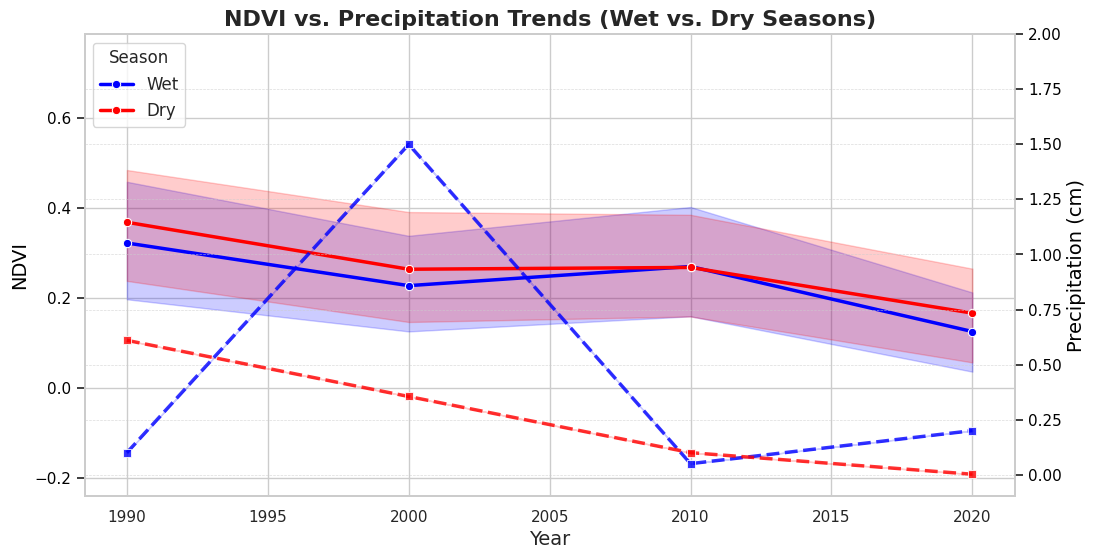

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber

# Load the PDF file and extract text
pdf_path = "/content/NDVI-Temp_Data.pdf"

# Extract text from the PDF
data_list = []
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            lines = text.split("\n")
            for line in lines:
                parts = line.split()
                if len(parts) == 6:  # Ensure there are six columns
                    try:
                        year = int(parts[0])
                        ndvi = float(parts[1])
                        season = parts[2]
                        evi = float(parts[3])
                        temp = float(parts[4]) if parts[4] != "NA" else None  # Handle NA
                        precip = float(parts[5]) if parts[5] != "NA" else None  # Handle NA
                        data_list.append([year, ndvi, season, evi, temp, precip])
                    except ValueError:
                        continue

# Convert extracted data to a DataFrame
columns = ["YEAR", "NDVI", "Season", "EVI", "Temp_0C", "Precip_cm"]
df = pd.DataFrame(data_list, columns=columns)

# Fill missing values using linear interpolation
df["Temp_0C"].interpolate(method="linear", inplace=True)
df["Precip_cm"].interpolate(method="linear", inplace=True)
# Removed dependency on ace_tools as this library is not installed.
# Using pandas to display the DataFrame instead.
print("Cleaned NDVI-Temp Data")
display(df)

# 🔹 Set the style for better aesthetics
sns.set_theme(style="whitegrid")

# 🔹 Create a new figure with a larger size for better readability
fig, ax1 = plt.subplots(figsize=(12, 6))

# 🔹 Define colors for Wet and Dry season trends
colors = {"Wet": "blue", "Dry": "red"}

# 🔹 Plot NDVI trends on the primary Y-axis (solid lines)
sns.lineplot(data=df, x="YEAR", y="NDVI", hue="Season", marker="o", ax=ax1, palette=colors, linewidth=2.5)
ax1.set_ylabel("NDVI", fontsize=14, color="black")
ax1.set_xlabel("Year", fontsize=14)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(df["NDVI"].min() - 0.1, df["NDVI"].max() + 0.1)  # Adjust NDVI range dynamically

# 🔹 Create a secondary Y-axis for Precipitation with proper separation
ax2 = ax1.twinx()
# Corrected: Use the correct column name "Precip_cm"
sns.lineplot(
    data=df, x="YEAR", y="Precip_cm", hue="Season", marker="s", linestyle="dashed",
    ax=ax2, palette=colors, linewidth=2.5, alpha=0.8, legend=False  # Disable duplicate legend
)
ax2.set_ylabel("Precipitation (cm)", fontsize=14, color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(df["Precip_cm"].min() - 0.1, df["Precip_cm"].max() + 0.5)  # Adjust precipitation range

# 🔹 Improve legend placement for clarity (Ensuring one legend only)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc="upper left", bbox_to_anchor=(0, 1), fontsize=12, title="Season")

# 🔹 Add title and improve gridlines
plt.title("NDVI vs. Precipitation Trends (Wet vs. Dry Seasons)", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)  # Softer gridlines for better visibility

# 🔹 Show the improved plot
plt.show()